In [1]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.81.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using ca


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Install Tensorflow

In [ ]:
import sys
import os

python_path = f'"{sys.executable}"'
!{python_path} -m pip install tensorflow


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Persiapan Dataset & Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

base_dir = 'TrashType_Image_Dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


2. Membangun Model dengan Strategi Fixed Feature Extractor

In [3]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

3. Tahapan Training 

In [6]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 453s 7s/step - accuracy: 0.2871 - loss: 2.4029 - val_accuracy: 0.5805 - val_loss: 1.2308
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 533s 8s/step - accuracy: 0.4007 - loss: 1.4227 - val_accuracy: 0.6302 - val_loss: 1.1688
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.4244 - loss: 1.3544 - val_accuracy: 0.5765 - val_loss: 1.0983
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 463s 7s/step - accuracy: 0.4659 - loss: 1.2835 - val_accuracy: 0.6421 - val_loss: 1.0132
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 497s 8s/step - accuracy: 0.5015 - loss: 1.2252 - val_accuracy: 0.6859 - val_loss: 0.9320
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 483s 8s/step - accuracy: 0.5183 - loss: 1.1913 - val_accuracy: 0.6680 - val_loss: 0.9035
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 436s 7s/step - accuracy: 0.5119 - loss: 1.1710 - val_accuracy: 0.7296 - val_loss: 0.9145
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 423s 7s/step - accuracy: 0.5385 - loss: 1.1326 - val_accuracy: 0.7197 - v

4. Pengujian Overfitting

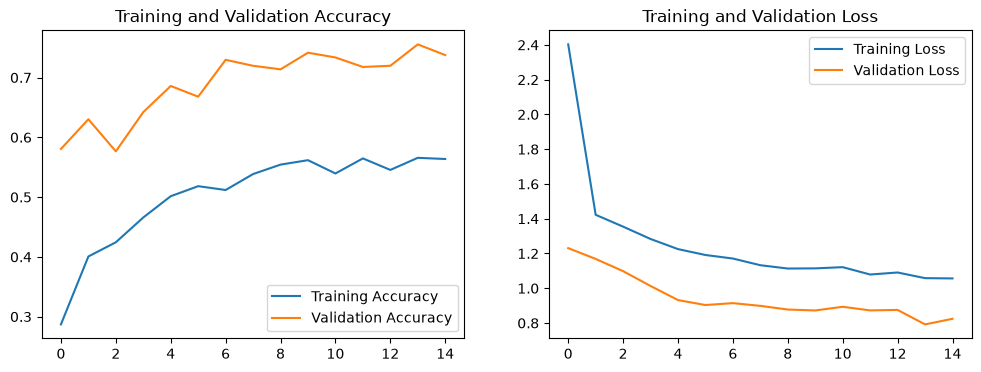

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Analisis Performa Model
Berdasarkan hasil training selama 15 epoch, model klasifikasi sampah menggunakan VGG16 menunjukkan peningkatan performa yang cukup baik. Training accuracy meningkat dari 28.71% menjadi 56.37%, sedangkan training loss menurun dari 2.4029 menjadi 1.0566. Hal ini menunjukkan bahwa model mampu mempelajari pola dan karakteristik gambar sampah secara bertahap selama proses training.

Pada data validasi, accuracy meningkat dari 58.05% menjadi 73.76%, dengan pencapaian terbaik sebesar 75.55% pada epoch ke-14. Validation loss juga mengalami penurunan dari 1.2308 menjadi 0.8244. Hasil tersebut menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik terhadap data yang tidak digunakan secara langsung dalam proses training.

# Evaluasi Overfitting
Berdasarkan perbandingan training loss dan validation loss, model tidak menunjukkan indikasi overfitting yang signifikan. Hal ini dapat dilihat dari validation loss yang secara umum mengalami penurunan selama proses training dan validation accuracy yang tetap stabil serta lebih tinggi dibandingkan training accuracy.

Perbedaan accuracy antara data training dan validasi dapat dipengaruhi oleh penerapan Data Augmentation pada data training. Proses augmentasi membuat gambar training menjadi lebih bervariasi dan lebih sulit dipelajari, sedangkan data validasi hanya mengalami normalisasi tanpa augmentasi.

Penerapan Freezing Layer pada VGG16 membantu mempertahankan fitur yang telah dipelajari sebelumnya, sedangkan penggunaan Dropout 0.5 membantu mengurangi risiko model terlalu bergantung pada neuron tertentu. Berdasarkan hasil tersebut, strategi yang digunakan cukup efektif dalam menjaga kemampuan generalisasi model.

# Kesimpulan
Model VGG16 berhasil mencapai validation accuracy terbaik sebesar 75.55% pada epoch ke-14. Selama proses training, loss cenderung menurun dan validation accuracy meningkat, sehingga model mampu melakukan klasifikasi dengan cukup baik tanpa menunjukkan indikasi overfitting yang signifikan. Namun, karena training accuracy masih sekitar 56%, model masih berpotensi ditingkatkan melalui fine-tuning beberapa layer VGG16, pengaturan learning rate, dan penambahan epoch dengan EarlyStopping serta ModelCheckpoint.